# Fargo multifluid

$\nu = 10^{-5}$, or $\alpha = 4\cdot 10^{-3}$

Inverse Stokes numbers are 10, 1, 0.1. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [26]:
particles=["gas", "dust1", "dust2", "dust3"]
paths=[]
rho_cube=np.array(rho_cube)
for part in particles:
    path = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/fargo_multifluid/{part}"
    paths.append(path)

In [30]:

max_n =100
rho_cube=[] # first index: which path, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in range(max_n+1):
        rho = np.fromfile(path+f"dens{i}.dat").reshape(128, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

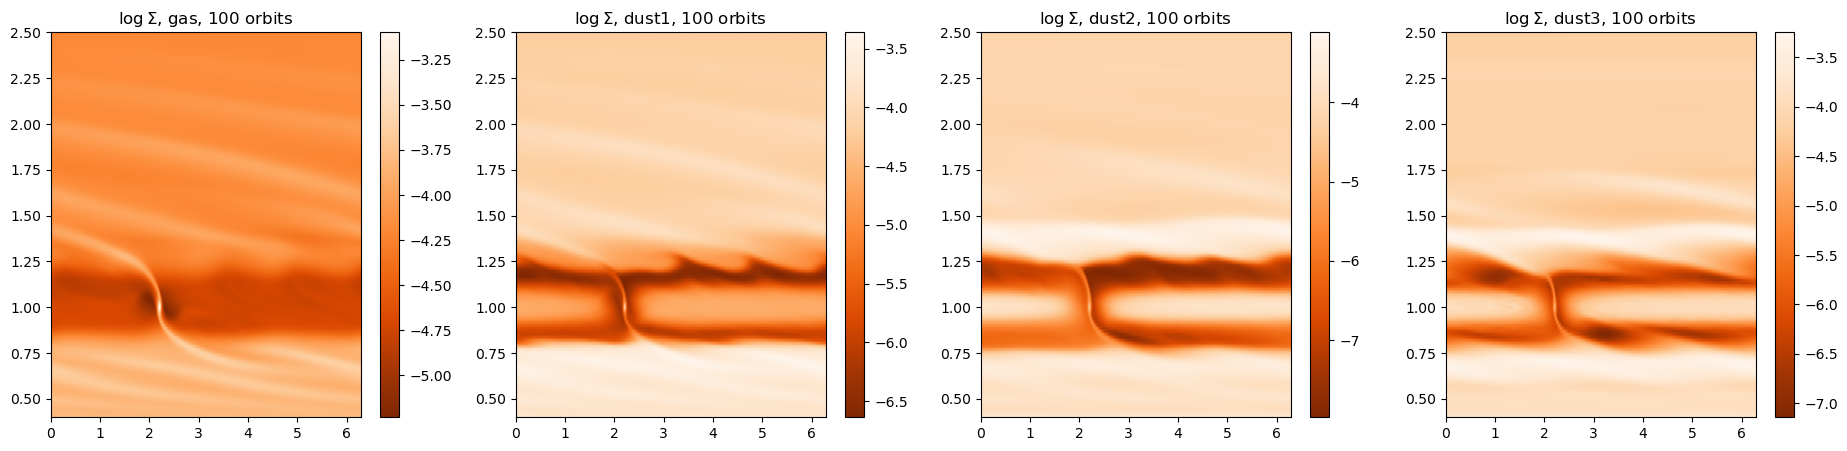

In [31]:
%matplotlib inline

n_frame=100
plt.figure(figsize=(23,5))
plt.subplot(1,4,1)
plt.imshow(np.log10(rho_cube[0][n_frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
plt.title(f"$\\log \\Sigma$, {particles[0]}, {n_frame} orbits")
plt.colorbar()

plt.subplot(1,4,2)
plt.imshow(np.log10(rho_cube[1][n_frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
plt.title(f"$\\log \\Sigma$, {particles[1]}, {n_frame} orbits")
plt.colorbar()

plt.subplot(1,4,3)
plt.imshow(np.log10(rho_cube[2][n_frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
plt.title(f"$\\log \\Sigma$, {particles[2]}, {n_frame} orbits")
plt.colorbar()

plt.subplot(1,4,4)
plt.imshow(np.log10(rho_cube[3][n_frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
plt.title(f"$\\log \\Sigma$, {particles[3]}, {n_frame} orbits")
plt.colorbar()
plt.show()


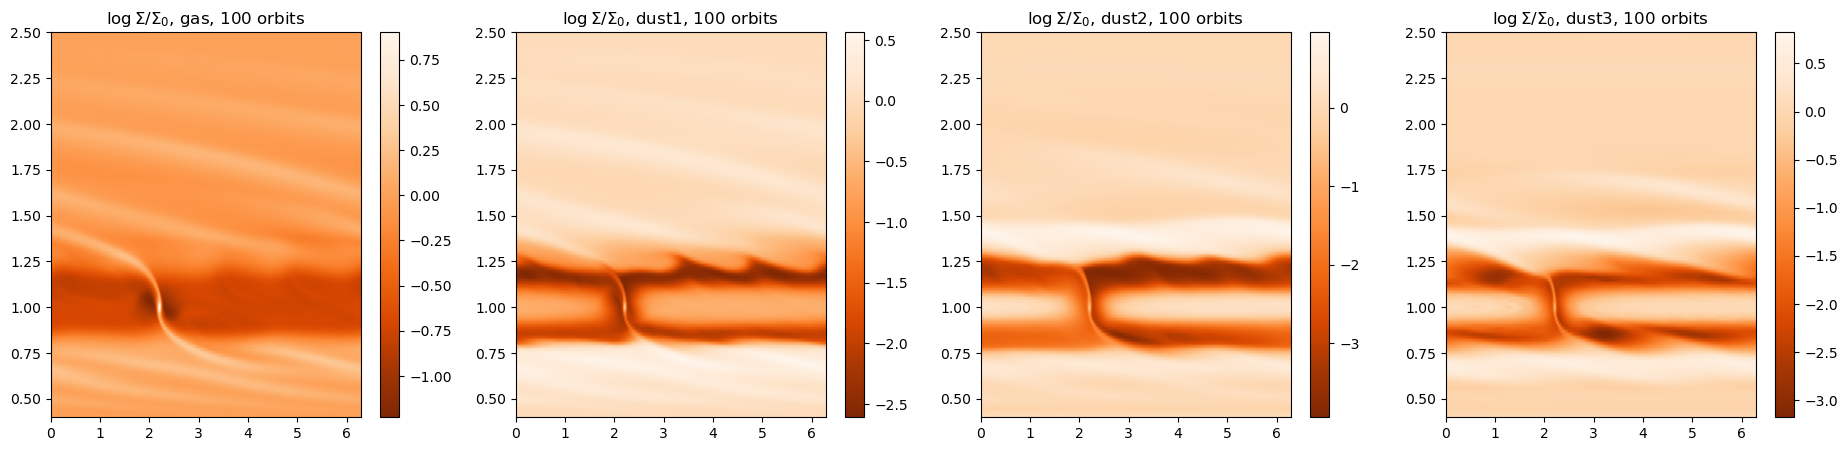

In [32]:
%matplotlib inline
n_frame=100
plt.figure(figsize=(23,5))
plt.subplot(1,4,1)
plt.imshow(np.log10(rho_cube[0][n_frame])-np.log10(rho_cube[0][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
plt.title(f"$\\log \\Sigma/\\Sigma_0$, {particles[0]}, {n_frame} orbits")
plt.colorbar()

plt.subplot(1,4,2)
plt.imshow(np.log10(rho_cube[1][n_frame])-np.log10(rho_cube[1][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
plt.title(f"$\\log \\Sigma/\\Sigma_0$, {particles[1]}, {n_frame} orbits")
plt.colorbar()

plt.subplot(1,4,3)
plt.imshow(np.log10(rho_cube[2][n_frame])-np.log10(rho_cube[2][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
plt.title(f"$\\log \\Sigma/\\Sigma_0$, {particles[2]}, {n_frame} orbits")
plt.colorbar()

plt.subplot(1,4,4)
plt.imshow(np.log10(rho_cube[3][n_frame])-np.log10(rho_cube[3][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
plt.title(f"$\\log \\Sigma/\\Sigma_0$, {particles[3]}, {n_frame} orbits")
plt.colorbar()
plt.show()

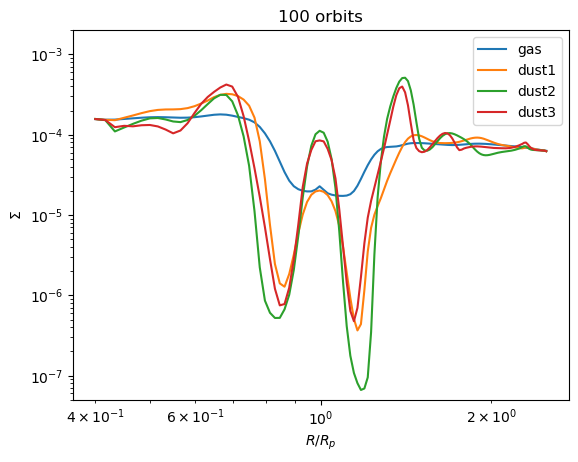

In [35]:
Ymin=0.4		#Inner boundary radius
Ymax=2.5
frame=100
rlist = np.linspace(Ymin,Ymax, len(rho_cube[2][49]))
# average surface density at radius r
rho_mean = np.mean(rho_cube, axis=3)
plt.plot(rlist,rho_mean[0][frame], label=f"{particles[0]}")
plt.plot(rlist,rho_mean[1][frame], label=f"{particles[1]}")
plt.plot(rlist,rho_mean[2][frame], label=f"{particles[2]}")
plt.plot(rlist,rho_mean[3][frame], label=f"{particles[3]}")
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma$")
plt.ylim(5e-8,2e-3)
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frame} orbits")
plt.legend()

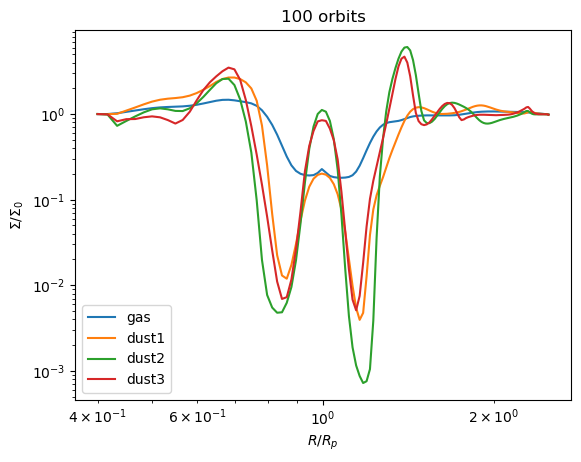

In [37]:
Ymin=0.4		#Inner boundary radius
Ymax=2.5
frame=100
rlist = np.linspace(Ymin,Ymax, len(rho_cube[2][49]))
# average surface density at radius r
rho_mean = np.mean(rho_cube, axis=3)
plt.plot(rlist,rho_mean[0][frame]/rho_mean[0][0], label=f"{particles[0]}")
plt.plot(rlist,rho_mean[1][frame]/rho_mean[1][0], label=f"{particles[1]}")
plt.plot(rlist,rho_mean[2][frame]/rho_mean[2][0], label=f"{particles[2]}")
plt.plot(rlist,rho_mean[3][frame]/rho_mean[3][0], label=f"{particles[3]}")
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
#plt.ylim(1e-4,2e-3)
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frame} orbits")
plt.legend()

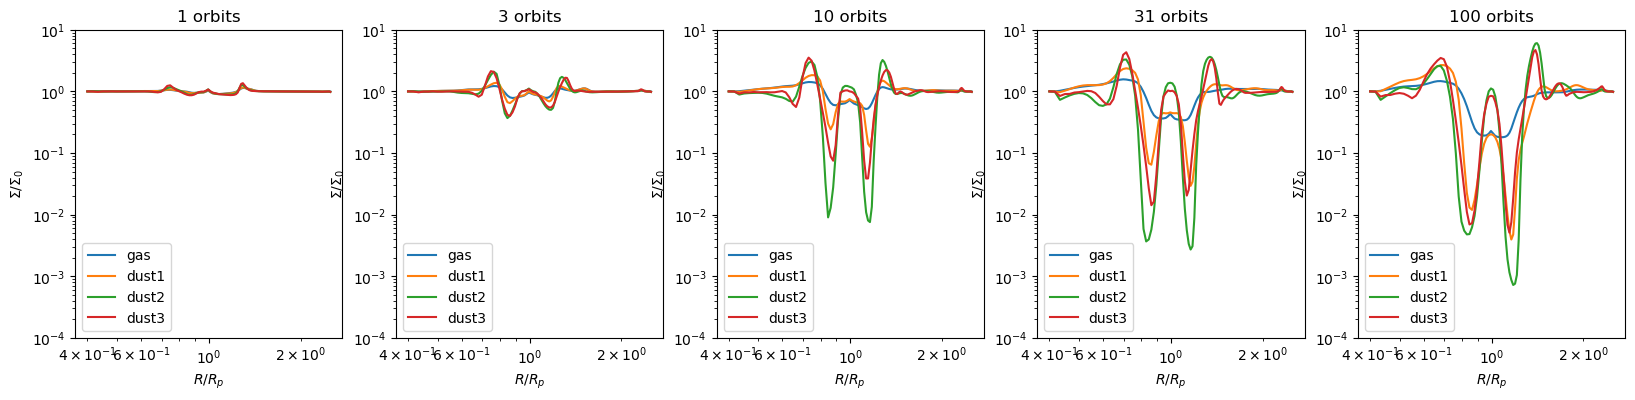

In [40]:
Ymin=0.4		#Inner boundary radius
Ymax=2.5
num_fig = 5
rlist = np.linspace(Ymin,Ymax, len(rho_cube[0][0]))
rho_mean = np.mean(rho_cube, axis=3)
frame_num = np.exp(np.log(10)*np.linspace(0,2,5))

plt.figure(figsize=(4*len(frame_num),4))

for i,frame in enumerate(frame_num):
    frame = int(frame)
    plt.subplot(1,len(frame_num),i+1)
    plt.plot(rlist,rho_mean[0][frame]/rho_mean[0][0], label=f"{particles[0]}")
    plt.plot(rlist,rho_mean[1][frame]/rho_mean[1][0], label=f"{particles[1]}")
    plt.plot(rlist,rho_mean[2][frame]/rho_mean[2][0], label=f"{particles[2]}")
    plt.plot(rlist,rho_mean[3][frame]/rho_mean[3][0], label=f"{particles[3]}")
    plt.xlabel("$R/R_p$")
    plt.ylabel("$\\Sigma/\\Sigma_0$")
    #plt.ylim(1e-4,2e-3)
    plt.xscale("log")
    plt.yscale("log")
    plt.ylim(1e-4,10)
    plt.title(f"{(frame)} orbits")
    plt.legend()

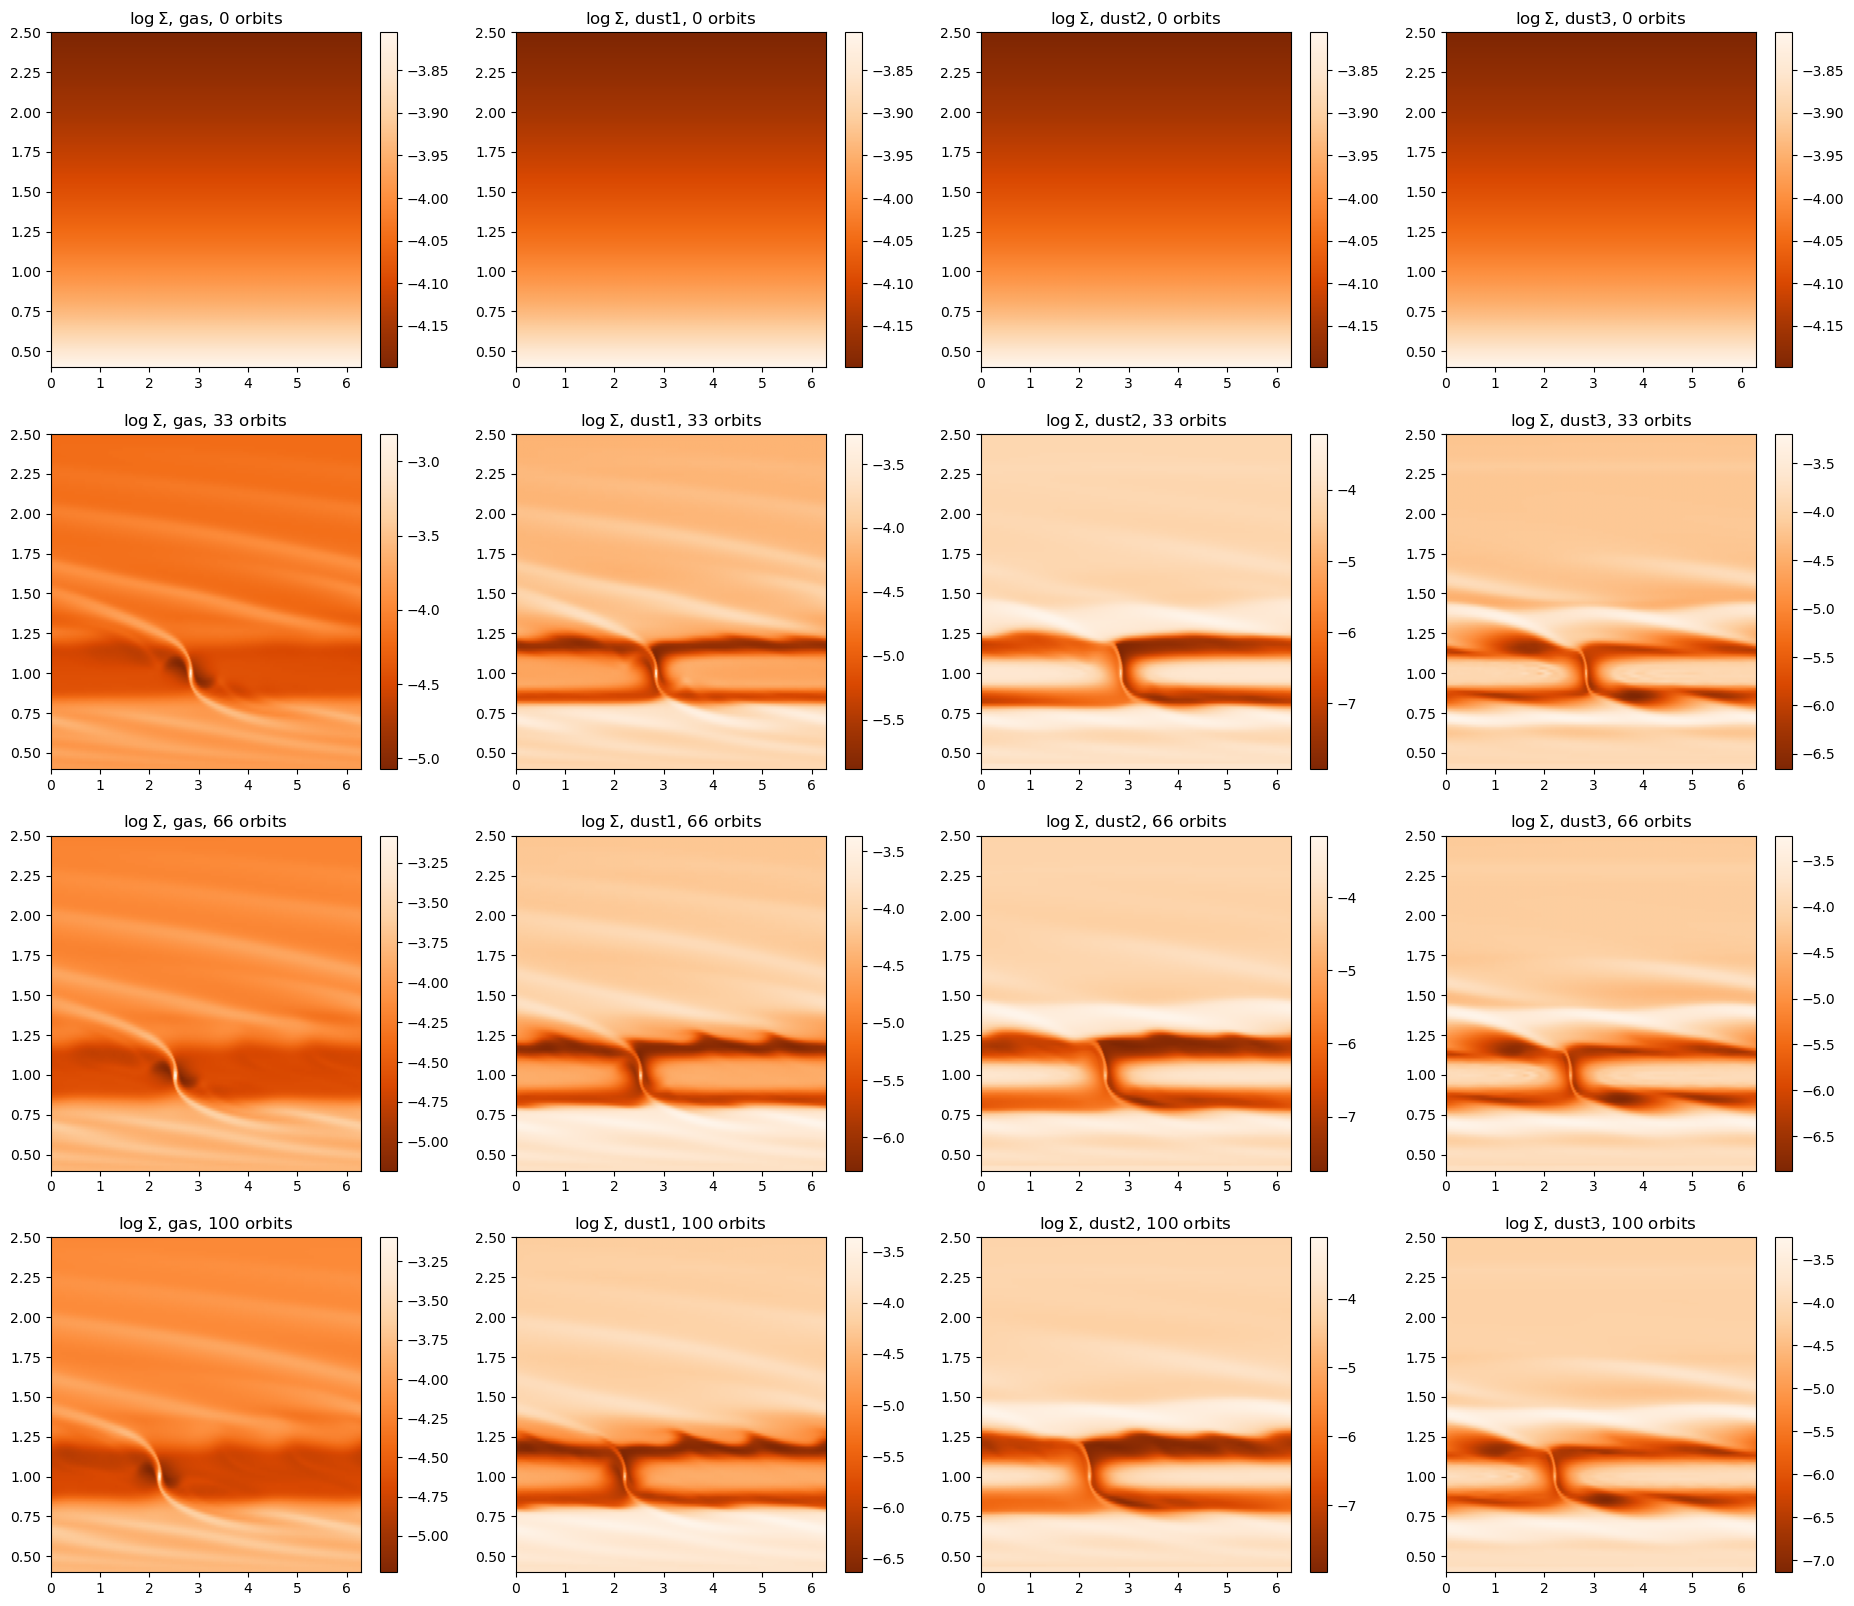

In [49]:
%matplotlib inline
frame_num = np.linspace(0,1,4)*max_n
plt.figure(figsize=(23,5*len(frame_num)))
for i,n_frame in enumerate(frame_num):
    n_frame=int(n_frame)
    plt.subplot(len(frame_num),4,1+4*i)
    plt.imshow(np.log10(rho_cube[0][n_frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
    plt.title(f"$\\log \\Sigma$, {particles[0]}, {(n_frame)} orbits")
    plt.colorbar()
    
    plt.subplot(len(frame_num),4,2+4*i)
    plt.imshow(np.log10(rho_cube[1][n_frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
    plt.title(f"$\\log \\Sigma$, {particles[1]}, {(n_frame)} orbits")
    plt.colorbar()
    
    plt.subplot(len(frame_num),4,3+4*i)
    plt.imshow(np.log10(rho_cube[2][n_frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
    plt.title(f"$\\log \\Sigma$, {particles[2]}, {(n_frame)} orbits")
    plt.colorbar()

    plt.subplot(len(frame_num),4,4+4*i)
    plt.imshow(np.log10(rho_cube[3][n_frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
    plt.title(f"$\\log \\Sigma$, {particles[3]}, {(n_frame)} orbits")
    plt.colorbar()

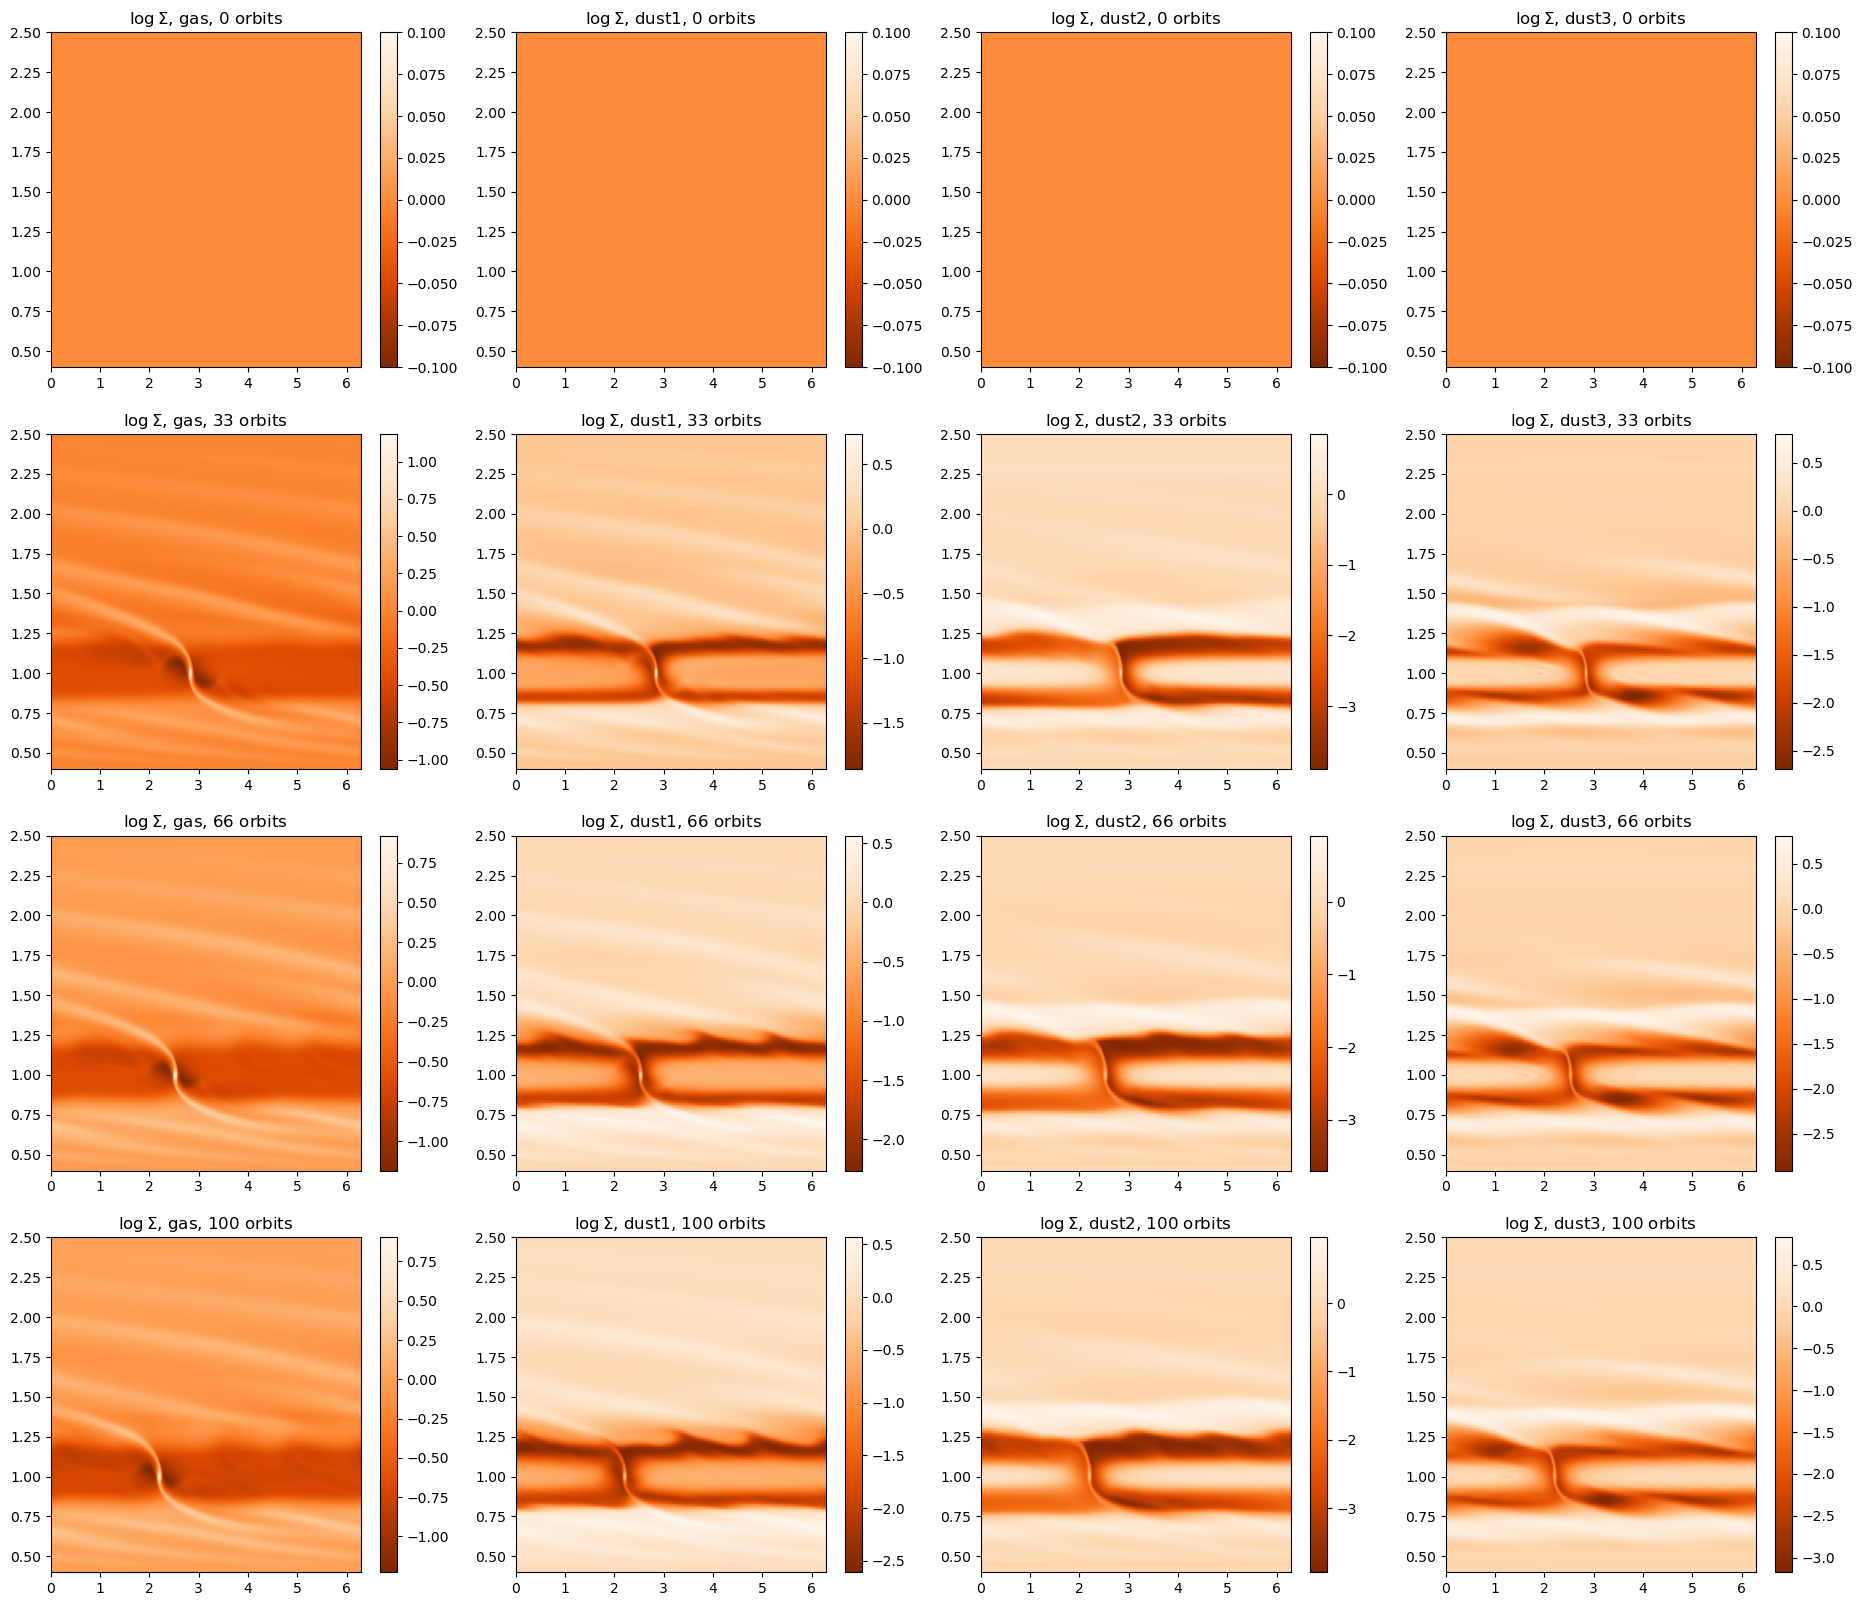

In [47]:
%matplotlib inline

%matplotlib inline
frame_num = np.linspace(0,1,4)*max_n
plt.figure(figsize=(23,5*len(frame_num)))
for i,n_frame in enumerate(frame_num):
    n_frame=int(n_frame)
    plt.subplot(len(frame_num),4,1+4*i)
    plt.imshow(np.log10(rho_cube[0][n_frame])-np.log10(rho_cube[0][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
    plt.title(f"$\\log \\Sigma$, {particles[0]}, {(n_frame)} orbits")
    plt.colorbar()
    
    plt.subplot(len(frame_num),4,2+4*i)
    plt.imshow(np.log10(rho_cube[1][n_frame])-np.log10(rho_cube[1][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
    plt.title(f"$\\log \\Sigma$, {particles[1]}, {(n_frame)} orbits")
    plt.colorbar()
    
    plt.subplot(len(frame_num),4,3+4*i)
    plt.imshow(np.log10(rho_cube[2][n_frame])-np.log10(rho_cube[2][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
    plt.title(f"$\\log \\Sigma$, {particles[2]}, {(n_frame)} orbits")
    plt.colorbar()

    plt.subplot(len(frame_num),4,4+4*i)
    plt.imshow(np.log10(rho_cube[3][n_frame])-np.log10(rho_cube[3][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
    plt.title(f"$\\log \\Sigma$, {particles[3]}, {(n_frame)} orbits")
    plt.colorbar()

# TODO:
- replace $\nu$ with $\alpha$ (or not? RADMC3D uses $\nu$)